[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/da380/PartIIStatistics/blob/main/notebooks/04_hypothesis_testing.ipynb)

# 4. Hypothesis testing

**What you should get out of this notebook**

- Understand the logic of a hypothesis test: null hypothesis, test statistic, p-value, significance level.
- Know what Type I and Type II errors and statistical power are, and how they trade off.
- Test whether a proposed model is compatible with data using the chi-squared statistic.
- Use the standard tests in `scipy.stats` for comparing means, distributions and counts.
- Recognise the common misuses of p-values.

**Tools introduced**

- `stats.ttest_1samp`, `stats.ttest_ind`, `stats.mannwhitneyu`
- `stats.chi2` and the `.sf` (survival function) method
- `stats.kstest`, `stats.ks_2samp`, `stats.shapiro`, `stats.chisquare`

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

rng = np.random.default_rng(1)          # random number generator with a fixed seed
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
DATA = "https://raw.githubusercontent.com/da380/PartIIStatistics/main/data/"

## The logic of a test

Much of science consists of asking whether data are consistent with some claim: that a sample's mean equals a reference value, that two populations are the same, that a model fits. A **hypothesis test** turns this into a procedure.

1. State a **null hypothesis** $H_0$, a precise claim about how the data were generated: "the mean is 5", "the two samples come from the same distribution", "these residuals are standard normal".
2. Choose a **test statistic** $T$, a number computed from the data that measures departure from $H_0$.
3. Work out the **sampling distribution of $T$ under $H_0$**: what values of $T$ would we see if $H_0$ were true and we repeated the experiment many times?
4. Compute the **p-value**: the probability, if $H_0$ is true, of obtaining a $T$ at least as extreme as the one observed.
5. If $p$ is below a pre-chosen **significance level** $\alpha$ (conventionally 0.05 or 0.01), **reject** $H_0$. Otherwise, do not reject it.

Step 3 is where the mathematics lives, and it is why so many named distributions exist: the $t$, $\chi^2$ and $F$ distributions are all sampling distributions of common test statistics. In practice `scipy.stats` does step 3 for you.

Two kinds of mistake are possible:

- **Type I error**: rejecting $H_0$ when it is true. By construction this happens with probability $\alpha$.
- **Type II error**: failing to reject $H_0$ when it is false. Its probability, $\beta$, depends on *how* false $H_0$ is and on the sample size. The **power** of the test, $1 - \beta$, is the probability of detecting a real effect.

Choosing $\alpha$ small makes Type I errors rare but Type II errors more common. There is no free lunch; the only way to reduce both is more or better data.

## The simplest test: is the mean equal to a reference value?

A laboratory measures the density of a standard whose certified value is 2.650 g cm$^{-3}$. Eight measurements are made. Is the laboratory's balance biased? The null hypothesis is that the measurements have mean 2.650. From Notebook 2, if $H_0$ is true then

$$
T = \frac{\hat{x} - 2.650}{s/\sqrt{n}}
$$

follows a $t$-distribution with $n-1$ degrees of freedom. A large $|T|$ is evidence against $H_0$. This is the **one-sample $t$-test**.

by hand:      T = 4.213, p = 0.0040
scipy:        T = 4.213, p = 0.0040


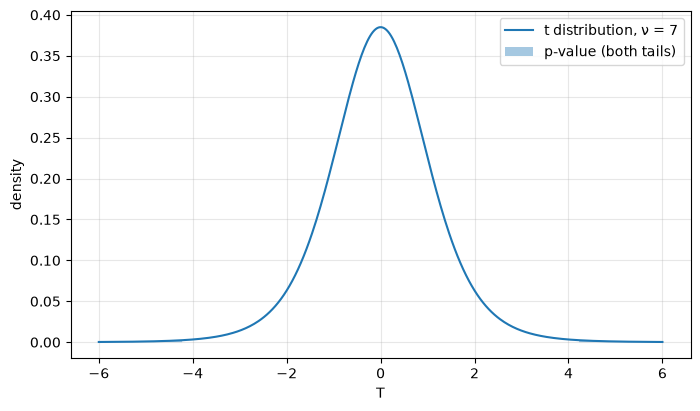

In [ ]:
x = np.array([2.663, 2.658, 2.671, 2.649, 2.667, 2.655, 2.672, 2.660])
mu0 = 2.650

# by hand
n = len(x)
T = (x.mean() - mu0) / stats.sem(x)
p = 2 * stats.t(n - 1).sf(abs(T))            # two-sided: both tails.  sf(t) = 1 - cdf(t)
print(f"by hand:      T = {T:.3f}, p = {p:.4f}")

# with scipy
res = stats.ttest_1samp(x, popmean=mu0)
print(f"scipy:        T = {res.statistic:.3f}, p = {res.pvalue:.4f}")

# where the observed T sits in the null distribution
tt = np.linspace(-6, 6, 400)
fig, ax = plt.subplots()
ax.plot(tt, stats.t(n - 1).pdf(tt), label=f"t distribution, ν = {n-1}")
ax.fill_between(tt, stats.t(n - 1).pdf(tt), where=np.abs(tt) >= abs(T), alpha=0.4, label="p-value (both tails)")
ax.set(xlabel="T", ylabel="density"); ax.legend()
plt.show()

With $p \approx 0.004$ we reject $H_0$ at the 5% (and 1%) level: the balance reads high. Two technical points:

- We used `sf`, the **survival function** $1 - F(t)$, rather than `1 - cdf(t)`. They are the same thing mathematically, but `sf` retains precision for very small p-values where `1 - cdf` would round to zero.
- The test is **two-sided**: we would have been equally interested in a bias in either direction, so both tails count. A one-sided test is appropriate only if a departure in one direction was ruled out *before* looking at the data.

### Checking the machinery: p-values under $H_0$ and the power of a test

If $H_0$ is true, the p-value is itself a random variable, and it is *uniformly distributed* on $[0, 1]$. That is exactly what makes the rule "reject if $p < \alpha$" produce a Type I error rate of $\alpha$. Let us verify this, and then see how power grows with sample size when $H_0$ is false.

fraction rejected at α = 0.05 when H0 is true: 0.046


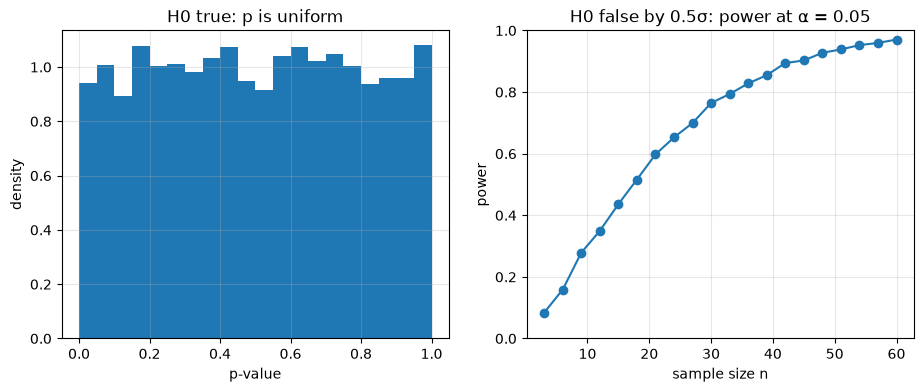

In [ ]:
n_sims = 5000
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# (a) H0 true: mean really is mu0
data = stats.norm(mu0, 0.01).rvs((n_sims, 8), random_state=rng)
p = stats.ttest_1samp(data, mu0, axis=1).pvalue
ax[0].hist(p, bins=20, density=True)
ax[0].set(xlabel="p-value", ylabel="density", title="H0 true: p is uniform")
print(f"fraction rejected at α = 0.05 when H0 is true: {np.mean(p < 0.05):.3f}")

# (b) H0 false: true mean is mu0 + 0.5 sigma. Power as a function of n.
sigma, shift = 0.01, 0.005
ns = np.arange(3, 61, 3)
power = []
for n in ns:
    data = stats.norm(mu0 + shift, sigma).rvs((n_sims, n), random_state=rng)
    p = stats.ttest_1samp(data, mu0, axis=1).pvalue
    power.append(np.mean(p < 0.05))
ax[1].plot(ns, power, "o-")
ax[1].set(xlabel="sample size n", ylabel="power", title="H0 false by 0.5σ: power at α = 0.05", ylim=(0, 1))
plt.show()

With an effect of half a standard deviation, eight measurements give a power of only about 25%: three times out of four the bias would go undetected. About 35 measurements are needed for 80% power. Calculations of this kind should be done *before* an experiment, to decide how much data to collect; a "non-significant" result from an underpowered experiment tells you very little.

## Testing a proposed model: the chi-squared test

Now a test that is central to the fitting of models in Notebook 5. Suppose the relationship between an input $x$ and an output $y$ is thought to be linear, $y = a x + b$, and somebody proposes specific values of $a$ and $b$. We have measurements $y_i$ at known $x_i$, each with a known error standard deviation $\sigma_i$. Is the proposed model compatible with the data?

Below we make some synthetic data, with true values $a = 2$, $b = -4$, and then forget that we know them.

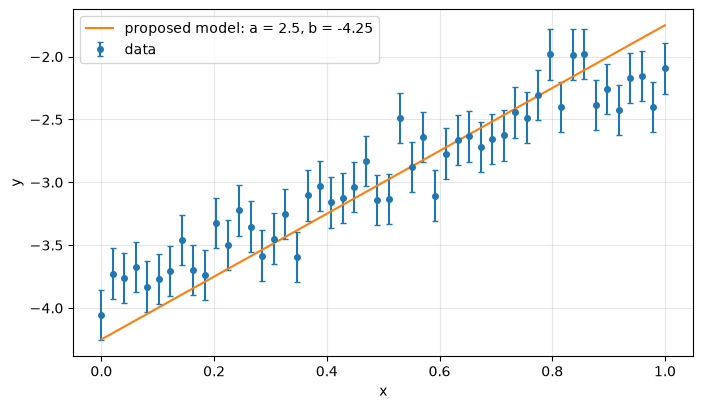

In [ ]:
n = 50
x = np.linspace(0, 1, n)
sigma = 0.2
y = 2*x - 4 + stats.norm(0, sigma).rvs(n, random_state=rng)

a_prop, b_prop = 2.5, -4.25          # the proposed model

fig, ax = plt.subplots()
ax.errorbar(x, y, yerr=sigma, fmt="o", ms=4, capsize=2, label="data")
ax.plot(x, a_prop*x + b_prop, "C1", label=f"proposed model: a = {a_prop}, b = {b_prop}")
ax.set(xlabel="x", ylabel="y"); ax.legend()
plt.show()

The model does not look terrible, but the points at small $x$ lie systematically above the line and those at large $x$ below. To make this quantitative, form the **normalised residuals**

$$
z_i = \frac{y_i - (a x_i + b)}{\sigma_i}.
$$

If the model is correct, each $z_i$ is a standard normal variable, and the sum of their squares

$$
\chi^2 = \sum_{i=1}^{n} z_i^2
$$

follows the **chi-squared distribution with $n$ degrees of freedom**. Its mean is $n$ and its standard deviation is $\sqrt{2n}$. So $\chi^2$ should be about $n$ if the model is right; much larger means the residuals are bigger than the errors can explain. The p-value is the probability of a $\chi^2$ this large or larger under $H_0$.

χ² = 83.2 with 50 degrees of freedom (expected about 50 ± 10);  p = 2.23e-03


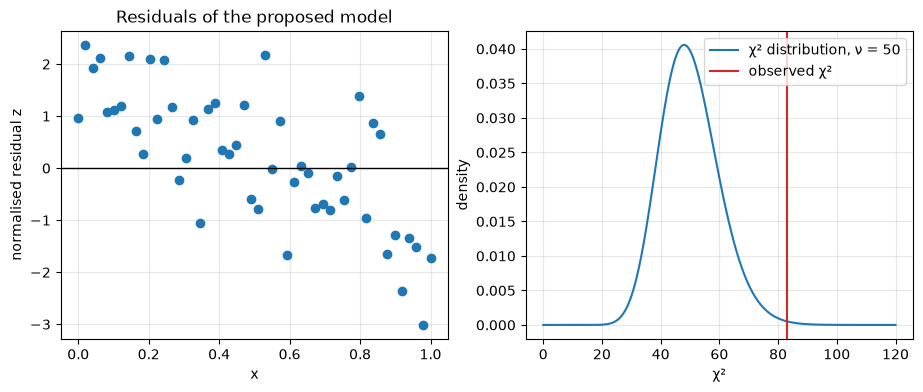

In [ ]:
z = (y - (a_prop*x + b_prop)) / sigma
chi2 = np.sum(z**2)
p = stats.chi2(n).sf(chi2)
print(f"χ² = {chi2:.1f} with {n} degrees of freedom (expected about {n} ± {np.sqrt(2*n):.0f});  p = {p:.2e}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(x, z, "o"); ax[0].axhline(0, color="k", lw=1)
ax[0].set(xlabel="x", ylabel="normalised residual z", title="Residuals of the proposed model")
cc = np.linspace(0, max(120, chi2 * 1.1), 400)
ax[1].plot(cc, stats.chi2(n).pdf(cc), label=f"χ² distribution, ν = {n}")
ax[1].axvline(chi2, color="C3", label="observed χ²")
ax[1].set(xlabel="χ²", ylabel="density"); ax[1].legend()
plt.show()

The observed $\chi^2$ is far out in the tail and the model is rejected decisively. The residual plot on the left shows *why*: a trend in the residuals, which is the classic sign of a wrong model. Always look at the residuals, not just the number.

Now try the true model. And try a model with the right parameters but with the errors *overestimated* by a factor of two.

In [ ]:
def chi2_test(a, b, sigma, label):
    z = (y - (a*x + b)) / sigma
    chi2 = np.sum(z**2)
    print(f"{label:45s} χ² = {chi2:6.1f},  reduced χ² = {chi2/n:.2f},  p = {stats.chi2(n).sf(chi2):.3f}")

chi2_test(2.5, -4.25, 0.2, "proposed model")
chi2_test(2.0, -4.00, 0.2, "true model")
chi2_test(2.0, -4.00, 0.4, "true model, errors overestimated ×2")

proposed model                                χ² =   83.2,  reduced χ² = 1.66,  p = 0.002
true model                                    χ² =   41.7,  reduced χ² = 0.83,  p = 0.792
true model, errors overestimated ×2           χ² =   10.4,  reduced χ² = 0.21,  p = 1.000


The **reduced chi-squared**, $\chi^2/\nu$, should be close to 1 for a good model with correctly estimated errors. A value much above 1 means the model is wrong or the errors are underestimated; a value much *below* 1 means the errors are overestimated (or, occasionally, that the data have been over-fitted). Only the first case is picked up by the one-sided p-value above; for the second you would look at the lower tail, `stats.chi2(n).cdf(chi2)`.

One more point, which matters in the next notebook. Here the model was *proposed in advance*, so all $n$ residuals were free to vary and $\nu = n$. If instead the parameters are *fitted* to the data, the fit uses up some of the freedom: with $p$ fitted parameters the appropriate distribution is $\chi^2$ with $\nu = n - p$ degrees of freedom.

## The standard toolkit

`scipy.stats` contains a test for most standard situations. The important thing is to know which question each answers and what it assumes. The examples use the Old Faithful and earthquake data from Notebook 1.

### Do two samples have the same mean?

The **two-sample $t$-test** (`ttest_ind`) tests whether two independent samples have the same mean, assuming each is roughly normal. Use `equal_var=False` (Welch's version), which does not assume the two groups have the same spread; there is almost never a reason not to. Its non-parametric cousin, the **Mann–Whitney U test**, compares the two distributions using ranks alone and needs no normality assumption; it is the safer choice for skewed data or small samples.

First a comparison where the answer is obvious (waiting times after short versus long eruptions), then one where it is not (waiting times in the first versus the second half of the record: has the geyser's behaviour changed?).

In [ ]:
faithful = pd.read_csv(DATA + "old_faithful.csv")
waiting = faithful["waiting"].to_numpy()
duration = faithful["eruptions"].to_numpy()

def compare(g1, g2, label):
    t = stats.ttest_ind(g1, g2, equal_var=False)
    u = stats.mannwhitneyu(g1, g2)
    print(f"{label}")
    print(f"   means {g1.mean():.1f} vs {g2.mean():.1f};   Welch t-test p = {t.pvalue:.2e};   Mann-Whitney p = {u.pvalue:.2e}")

compare(waiting[duration < 3], waiting[duration >= 3], "after short vs long eruptions")
half = len(waiting) // 2
compare(waiting[:half], waiting[half:], "first half vs second half of the record")

after short vs long eruptions
   means 54.5 vs 80.0;   Welch t-test p = 4.82e-86;   Mann-Whitney p = 2.90e-42
first half vs second half of the record
   means 70.8 vs 71.0;   Welch t-test p = 9.01e-01;   Mann-Whitney p = 9.22e-01


The first difference is overwhelming. For the second there is no evidence of a change: the p-values are large. Note the wording. We have not shown that the two halves *are* the same; we have failed to find evidence that they differ, which is a weaker statement whose strength depends on the power of the test.

### Does a sample follow a given distribution?

The **Kolmogorov–Smirnov test** (`kstest`) compares the empirical CDF of a sample with a specified CDF; its statistic is the largest vertical gap between them. In Notebook 1 we fitted an exponential distribution to the times between large earthquakes and noticed an excess of short gaps. Is the excess statistically significant?

In [ ]:
quakes = pd.read_csv(DATA + "usgs_earthquakes_M5_2014_2023.csv", parse_dates=["time"])
big = quakes[quakes["mag"] >= 6.5].sort_values("time")
gaps = np.diff(big["time"].to_numpy()) / np.timedelta64(1, "D")
E = stats.expon(scale=gaps.mean())

res = stats.kstest(gaps, E.cdf)
print(f"KS statistic = {res.statistic:.3f}, p = {res.pvalue:.4f}")

KS statistic = 0.079, p = 0.0073


The exponential model is rejected at the 1% level: the clustering of large earthquakes is real, not a sampling fluctuation. (A subtlety: we fitted the rate to the same data we then tested, which makes the true p-value somewhat larger than reported. For a single fitted parameter and this many data the effect is modest, but it is worth knowing about.)

The **Shapiro–Wilk test** (`shapiro`) is the standard test for normality. Here it is applied to the waiting times after long eruptions, which the Q-Q plot of Notebook 1 suggested were roughly normal, and to all waiting times, which are clearly not.

In [ ]:
for name, sample in [("after long eruptions", waiting[duration >= 3]), ("all waiting times", waiting)]:
    res = stats.shapiro(sample)
    print(f"{name:22s}: Shapiro-Wilk W = {res.statistic:.3f}, p = {res.pvalue:.2e}")

after long eruptions  : Shapiro-Wilk W = 0.994, p = 6.48e-01
all waiting times     : Shapiro-Wilk W = 0.922, p = 1.02e-10


### Are counts consistent with expectation?

The **chi-squared test for counts** (`chisquare`) compares observed counts in categories with the counts expected under $H_0$, via $\chi^2 = \sum (O - E)^2 / E$. Here: is the annual number of magnitude 6.5+ earthquakes consistent with a constant rate?

In [ ]:
counts = big["time"].dt.year.value_counts().sort_index()
res = stats.chisquare(counts.to_numpy())          # expected counts default to the mean
print("annual counts:", counts.to_numpy())
print(f"χ² = {res.statistic:.1f} with {len(counts)-1} degrees of freedom, p = {res.pvalue:.3f}")

annual counts: [54 58 46 39 44 33 29 45 42 53]
χ² = 17.1 with 9 degrees of freedom, p = 0.048


The result is borderline: $p$ is just under 0.05, so there is modest evidence that the year-to-year variation exceeds what a constant-rate process would produce, consistent with the clustering seen earlier. Ten years is not many; Notebook 8 shows how simulation can build the null distribution for questions of this kind directly. Note that the degrees of freedom are $\nu = 10 - 1 = 9$: one is lost because the expected counts were set from the observed total.

### A guide to choosing

| Question | Parametric test | Non-parametric alternative |
|---|---|---|
| Is the mean equal to $\mu_0$? | `ttest_1samp` | `wilcoxon` (on $x - \mu_0$) |
| Do two independent groups differ? | `ttest_ind(equal_var=False)` | `mannwhitneyu` |
| Do paired measurements differ? | `ttest_rel` | `wilcoxon` |
| Do several groups differ? | `f_oneway` (ANOVA) | `kruskal` |
| Does a sample follow distribution $F$? | `kstest`, `shapiro` (normal) | |
| Do two samples follow the same distribution? | `ks_2samp` | `mannwhitneyu` |
| Are counts consistent with expected? | `chisquare`, `chi2_contingency` | |
| Are two variables correlated? | `pearsonr` | `spearmanr` (Notebook 6) |

Parametric tests assume a distributional form (usually normal) and are more powerful when the assumption holds; non-parametric tests are robust when it does not. For large samples the central limit theorem makes the $t$-tests robust anyway.

## What a p-value is not, and other pitfalls

- **The p-value is not the probability that $H_0$ is true.** It is the probability of the data (or more extreme data) *given* $H_0$. Within the frequentist framework $H_0$ is simply true or false, with no probability attached. Bayesian methods (Notebook 7) do allow one to speak of the probability of a hypothesis, but they need a prior.
- **Statistical significance is not scientific importance.** With enough data, any tiny departure from $H_0$ becomes significant, because no model is exactly true. Always report the *size* of the effect with its uncertainty, not just the p-value.
- **Failing to reject is not confirming.** A large p-value may just reflect low power.
- **Multiple comparisons.** If you perform 20 independent tests at $\alpha = 0.05$ on data where $H_0$ is true throughout, you expect one "significant" result by chance. Testing many hypotheses and reporting the ones that pass is a reliable way to generate false discoveries. The simplest correction is Bonferroni's: use $\alpha / m$ for $m$ tests.
- **Choose the test before seeing the data.** Switching between one- and two-sided tests, or between test statistics, after looking at the result invalidates the p-value.

The multiple comparisons problem is easy to demonstrate.

In [ ]:
m = 20
noise = stats.norm(0, 1).rvs((m, 10), random_state=rng)      # 20 samples of pure noise, all with true mean 0
p = stats.ttest_1samp(noise, 0, axis=1).pvalue
print("p-values of 20 tests on pure noise, sorted:")
print(np.round(np.sort(p), 3))
print(f"'significant' at 0.05:               {np.sum(p < 0.05)} of {m}")
print(f"significant with Bonferroni 0.05/{m}: {np.sum(p < 0.05/m)} of {m}")

p-values of 20 tests on pure noise, sorted:
[0.02  0.079 0.129 0.166 0.252 0.295 0.298 0.299 0.309 0.315 0.358 0.432
 0.729 0.734 0.808 0.809 0.853 0.883 0.888 0.95 ]
'significant' at 0.05:               1 of 20
significant with Bonferroni 0.05/20: 0 of 20


## Summary

- A hypothesis test asks how surprising the data would be if the null hypothesis were true; the p-value quantifies the surprise.
- $\alpha$ fixes the Type I error rate; power depends on effect size and sample size and should be considered before collecting data.
- The chi-squared statistic tests a proposed model against data with known errors; its reduced value should be near 1, and the residuals should show no structure.
- `scipy.stats` has a test for every standard situation; know what each assumes.
- A p-value is not the probability of the hypothesis, significance is not importance, and testing many things finds false positives.

## Exercises

### Exercise 1

Repeat the chi-squared test of the proposed straight line with the proposal $(a, b) = (2.1, -4.05)$. Is it rejected at the 5% level? Plot the residuals. Then repeat with the true $(2, -4)$ but with the error standard deviation *underestimated*, using $\sigma = 0.1$ in the test. What happens, and what lesson does it teach about the importance of honest error estimates?

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
chi2_test(2.1, -4.05, 0.2, "proposal (2.1, -4.05)")
chi2_test(2.0, -4.00, 0.1, "true model, errors underestimated ×2")

z = (y - (2.1*x - 4.05)) / sigma
fig, ax = plt.subplots(); ax.plot(x, z, "o"); ax.axhline(0, color="k", lw=1)
ax.set(xlabel="x", ylabel="normalised residual"); plt.show()
```

The nearby proposal is not rejected (the exact p-value depends on the random data; it should be well above 0.05), and its residuals show only a faint trend. With the errors underestimated by a factor of two the *true* model is rejected, with $\chi^2$ more than three times $n$ (each normalised residual is doubled, so $\chi^2$ is quadrupled relative to its value with the correct $\sigma$). The chi-squared test is only as good as the error estimates fed into it; underestimating errors leads to rejecting correct models, overestimating them to accepting wrong ones.

</details>

### Exercise 2

Use `stats.ks_2samp` to test whether the distribution of earthquake magnitudes (all events, magnitude 5 and above) differs between 2014–2018 and 2019–2023. Then do the same for the depths. Do the results surprise you? Plot the two empirical CDFs of depth to see what the test is picking up.

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
early = quakes[quakes["time"].dt.year <= 2018]
late = quakes[quakes["time"].dt.year >= 2019]
for col in ["mag", "depth"]:
    res = stats.ks_2samp(early[col], late[col])
    print(f"{col:6s}: KS statistic = {res.statistic:.3f}, p = {res.pvalue:.3g}")

fig, ax = plt.subplots()
stats.ecdf(early["depth"]).cdf.plot(ax, label="2014–2018")
stats.ecdf(late["depth"]).cdf.plot(ax, label="2019–2023")
ax.set(xlabel="depth (km)", ylabel="CDF", xscale="log"); ax.legend(); plt.show()
```

The magnitude distributions are indistinguishable, as one would hope for a global catalogue over two similar periods. The depth distributions differ overwhelmingly ($p \sim 10^{-21}$), even though the largest gap between the CDFs is only about 7%. With over 8,000 events in each half, even small differences are detected: partly where the large subduction-zone sequences happened to occur, and partly changes in the agency's practice of assigning fixed depths to poorly constrained events. A significant test tells you that two samples differ, not *why*; that is a scientific question, not a statistical one.

</details>

### Exercise 3

The power calculation above used a shift of $0.5\sigma$. Estimate by simulation the sample size needed for 80% power to detect a shift of $0.2\sigma$ with a two-sided one-sample $t$-test at $\alpha = 0.05$. (You may want to try $n$ = 50, 100, 200, 400.)

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
for n in [50, 100, 200, 400]:
    data = stats.norm(0.2, 1).rvs((4000, n), random_state=rng)
    power = np.mean(stats.ttest_1samp(data, 0, axis=1).pvalue < 0.05)
    print(f"n = {n:3d}: power = {power:.2f}")
```

About 200 measurements are needed. The required $n$ scales roughly as the inverse square of the effect size: a 2.5 times smaller effect needs about 6 times more data than the 35 found for $0.5\sigma$.

</details>